In [66]:
# --- Símbolo ---
# Definido una sola vez: todas las celdas de este notebook (Prophet diario y
# reflectivo, patrones armónicos, probabilidad de targets) reutilizan SYMBOL en
# sus llamadas a yf.download() y SYMBOL_LABEL en los títulos/etiquetas de los gráficos.
#
# ⚠️ No todos los tickers "razonables" existen en yfinance. Verificados y funcionando:
#   - "ETH-USD"  -> Ethereum
#   - "PAXG-USD" -> Oro (token respaldado 1:1 por oro físico LBMA; sigue el spot
#                   XAU/USD real, a diferencia de "XAU-USD"/"XAUUSD"/"GC=F", que
#                   devuelven datos vacíos, casi vacíos o con prima de futuros).
SYMBOL = "PAXG-USD"
SYMBOL_LABEL = "XAUUSD"

[*********************100%***********************]  1 of 1 completed
17:57:26 - cmdstanpy - INFO - Chain [1] start processing
17:57:26 - cmdstanpy - INFO - Chain [1] done processing


ds    datetime64[s]
y           float64
dtype: object
          ds            y
0 2025-08-23  3359.250244
1 2025-08-24  3359.708740
2 2025-08-25  3342.993408
3 2025-08-26  3378.823486
4 2025-08-27  3388.906494


d:\Documentos\Trabajos\Laboratorios\NOTEBOOK_ESTADISTICA_CRYPTO\env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


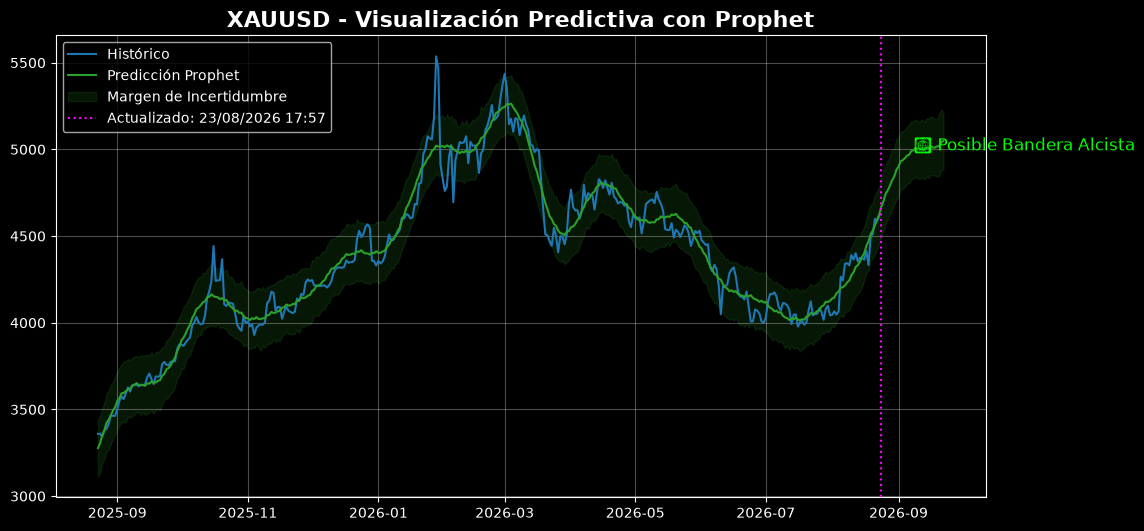

In [67]:
# 📈 Visualización Predictiva con IA para ETH/USD
import yfinance as yf # Datos de Yahoo Finance
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from prophet import Prophet

# 1️⃣ Descargar datos históricos
data = yf.download(SYMBOL, period="1y", interval="1d")

# 2️⃣ Preparar DataFrame limpio para Prophet
df = pd.DataFrame({
    "ds": pd.to_datetime(data.index),   # índice convertido a datetime
    "y": data["Close"].values.flatten().astype(float)  # aplanar y forzar float
}).dropna()

print(df.dtypes)   # Verificación: ds debe ser datetime64[ns], y float64
print(df.head())   # Verificar primeras filas

# 3️⃣ Entrenar modelo Prophet
model = Prophet(daily_seasonality=True, yearly_seasonality=True, interval_width=0.95)
model.fit(df)

# 4️⃣ Generar predicción a 30 días
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# 5️⃣ Visualización profesional
plt.figure(figsize=(12, 6))
plt.plot(df["ds"], df["y"], color="#1f77b4", label="Histórico")
plt.plot(forecast["ds"], forecast["yhat"], color="#2ca02c", label="Predicción Prophet")
plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"],
                 color="#2ca02c", alpha=0.15, label="Margen de Incertidumbre")

# 6️⃣ Detección de patrón emergente (simplificada)
trend = forecast["yhat"].diff().tail(10).mean()
if trend > 0:
    plt.text(forecast["ds"].iloc[-15], forecast["yhat"].iloc[-15],
             "📈 Posible Bandera Alcista", color="lime", fontsize=12)
else:
    plt.text(forecast["ds"].iloc[-15], forecast["yhat"].iloc[-15],
             "📉 Posible Cuña Descendente", color="red", fontsize=12)

# 7️⃣ Marcar fecha y hora de actualización del gráfico
ahora = datetime.now()
plt.axvline(ahora, color="magenta", linestyle=":", linewidth=1.5, zorder=5,
            label=f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}")

plt.title(f"{SYMBOL_LABEL} - Visualización Predictiva con Prophet", fontsize=16, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 📊 Exportar datos predictivos de ETH/USD para Power BI

In [68]:
# 📊 Exportar datos predictivos de ETH/USD para Power BI
import yfinance as yf
import pandas as pd
from prophet import Prophet

# 1️⃣ Descargar datos históricos
data = yf.download(SYMBOL, period="1y", interval="1d")

# 2️⃣ Preparar datos para Prophet (aplanar columna Close)
df = pd.DataFrame({
    "ds": pd.to_datetime(data.index),              # índice convertido a datetime
    "y": data["Close"].squeeze().astype(float)     # aplanar y forzar float
}).dropna()

print(df.dtypes)   # Verificación: ds debe ser datetime64[ns], y float64
print(df.head())

# 3️⃣ Entrenar modelo Prophet
model = Prophet(daily_seasonality=True, yearly_seasonality=True, interval_width=0.95)
model.fit(df)

# 4️⃣ Generar predicción a 30 días
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# 5️⃣ Unir histórico y predicción
merged = pd.merge(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]],
                  df[["ds", "y"]],
                  on="ds", how="left")

# 6️⃣ Renombrar columnas para Power BI
merged = merged.rename(columns={
    "ds": "Fecha",
    "y": "Historico",
    "yhat": "Prediccion_IA",
    "yhat_lower": "Margen_Inferior",
    "yhat_upper": "Margen_Superior"
})

# 7️⃣ Exportar a Excel (recomendado para Power BI) - hola
merged.to_excel(f"{SYMBOL_LABEL}_Predictivo.xlsx", index=False)

print(merged.tail())


[*********************100%***********************]  1 of 1 completed
17:57:26 - cmdstanpy - INFO - Chain [1] start processing
17:57:26 - cmdstanpy - INFO - Chain [1] done processing


ds    datetime64[s]
y           float64
dtype: object
                   ds            y
Date                              
2025-08-23 2025-08-23  3359.250244
2025-08-24 2025-08-24  3359.708740
2025-08-25 2025-08-25  3342.993408
2025-08-26 2025-08-26  3378.823486
2025-08-27 2025-08-27  3388.906494
         Fecha  Prediccion_IA  Margen_Inferior  Margen_Superior  Historico
391 2026-09-18    5010.552605      4846.788621      5183.046263        NaN
392 2026-09-19    5017.410542      4854.577049      5193.112310        NaN
393 2026-09-20    5019.076712      4848.154056      5184.617784        NaN
394 2026-09-21    5041.154290      4872.022255      5218.362947        NaN
395 2026-09-22    5049.232344      4885.364897      5211.516272        NaN


[*********************100%***********************]  1 of 1 completed
d:\Documentos\Trabajos\Laboratorios\NOTEBOOK_ESTADISTICA_CRYPTO\env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128999 (\N{LARGE ORANGE SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Documentos\Trabajos\Laboratorios\NOTEBOOK_ESTADISTICA_CRYPTO\env\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 128100 (\N{BUST IN SILHOUETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


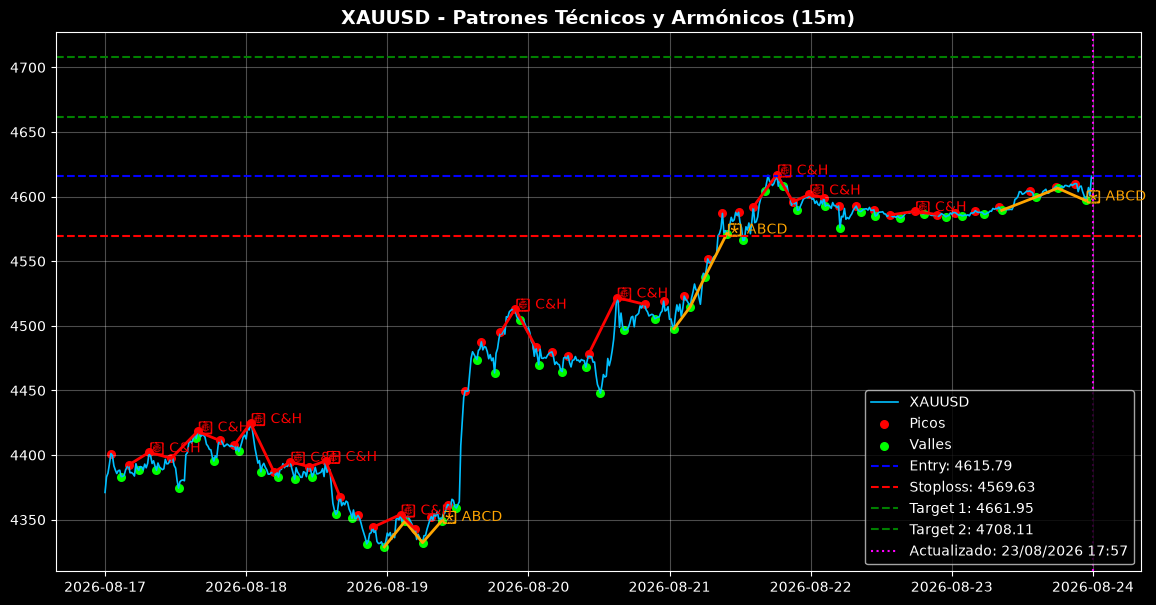

In [69]:
# 📈 Detección de patrones técnicos y armónicos en ETH/USD (15m)
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import find_peaks

# 1️⃣ Descargar datos en intervalos de 15 minutos
data = yf.download(SYMBOL, period="7d", interval="15m").dropna()

# 2️⃣ Asegurar que 'Close' sea un array 1D plano
close = data["Close"].squeeze().astype(float).values
time = data.index

# 3️⃣ Detectar picos y valles
peaks, _ = find_peaks(close, distance=10)
valleys, _ = find_peaks(-close, distance=10)

# 4️⃣ Detectar patrón armónico ABCD (simplificado)
patterns = []
for i in range(len(valleys) - 3):
    X, A, B, D = valleys[i:i+4]
    XA = abs(close[A] - close[X])
    AB = abs(close[B] - close[A])
    BD = abs(close[D] - close[B])
    ratio1 = AB / XA
    ratio2 = BD / AB
    if 0.618 < ratio1 < 1.618 and 0.618 < ratio2 < 1.618:
        patterns.append((X, A, B, D))

# 5️⃣ Cabeza y hombros (simplificado)
chs = []
for i in range(2, len(peaks) - 2):
    L, H, R = peaks[i-1], peaks[i], peaks[i+1]
    if close[H] > close[L] and close[H] > close[R]:
        chs.append((L, H, R))

# 6️⃣ Visualización tipo TradingView
plt.figure(figsize=(14,7))
plt.plot(time, close, color="#00bfff", linewidth=1.2, label=SYMBOL_LABEL)
plt.scatter(time[peaks], close[peaks], color="red", s=30, label="Picos")
plt.scatter(time[valleys], close[valleys], color="lime", s=30, label="Valles")

# Dibujar patrones armónicos
for (X, A, B, D) in patterns:
    plt.plot([time[X], time[A], time[B], time[D]],
             [close[X], close[A], close[B], close[D]],
             color="orange", linewidth=2)
    plt.text(time[D], close[D], "🟧 ABCD", color="orange", fontsize=10)

# Dibujar cabeza y hombros
for (L, H, R) in chs:
    plt.plot([time[L], time[H], time[R]],
             [close[L], close[H], close[R]],
             color="red", linewidth=2)
    plt.text(time[H], close[H], "👤 C&H", color="red", fontsize=10)

# Zonas de entrada y objetivos
entry = close[-1]
stoploss = entry * 0.99
target1 = entry * 1.01
target2 = entry * 1.02

plt.axhline(entry, color="blue", linestyle="--", label=f"Entry: {entry:.2f}")
plt.axhline(stoploss, color="red", linestyle="--", label=f"Stoploss: {stoploss:.2f}")
plt.axhline(target1, color="green", linestyle="--", label=f"Target 1: {target1:.2f}")
plt.axhline(target2, color="green", linestyle="--", label=f"Target 2: {target2:.2f}")

# 7️⃣ Marcar fecha y hora de actualización del gráfico
ahora = datetime.now()
ahora_plot = ahora.astimezone(time.tz) if time.tz is not None else ahora
plt.axvline(ahora_plot, color="magenta", linestyle=":", linewidth=1.5, zorder=5,
            label=f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}")

plt.title(f"{SYMBOL_LABEL} - Patrones Técnicos y Armónicos (15m)", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

[*********************100%***********************]  1 of 1 completed


📊 Probabilidades históricas (últimos 30 días):
- Target 1 alcanzado: 2.43%
- Target 2 alcanzado: 0.00%
- Stoploss tocado: 0.38%


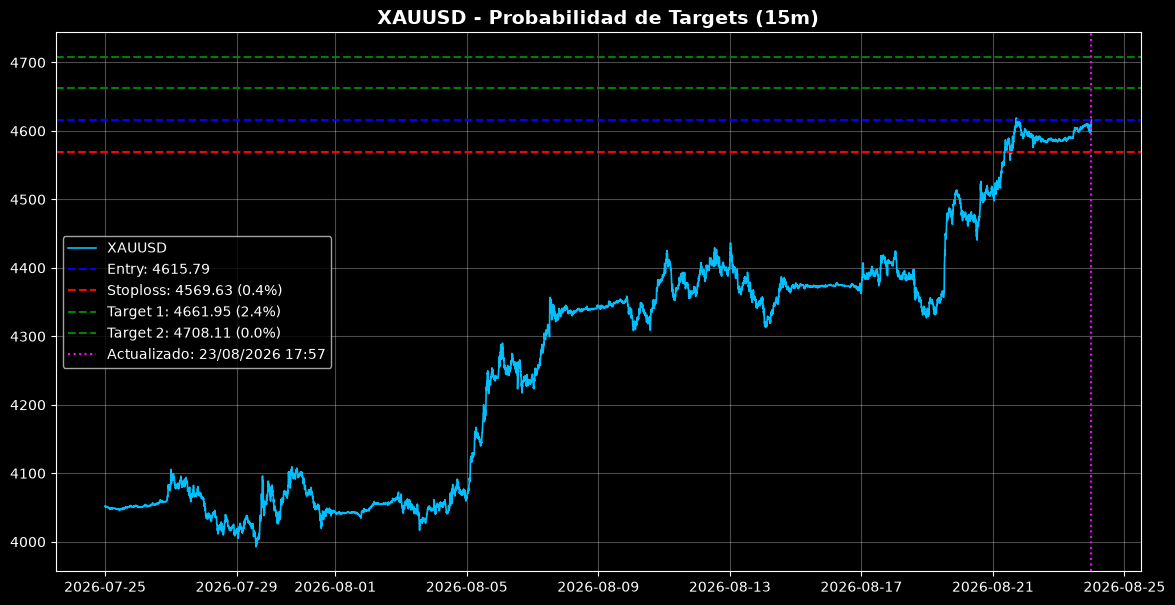

In [70]:
# 📊 Detección de patrones + Probabilidad de targets
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import find_peaks

# 1️⃣ Descargar datos en intervalos de 5 minutos
data = yf.download(SYMBOL, period="30d", interval="5m").dropna()
close = data["Close"].squeeze().astype(float).values
time = data.index

# 2️⃣ Detectar picos y valles
peaks, _ = find_peaks(close, distance=10)
valleys, _ = find_peaks(-close, distance=10)

# 3️⃣ Definir entrada y objetivos
entry = close[-1]
stoploss = entry * 0.99
target1 = entry * 1.01
target2 = entry * 1.02

# 4️⃣ Calcular probabilidad de alcanzar targets
# Usamos ventanas históricas de 30 barras (7.5 horas aprox.)
window = 30
results = {"Target1":0, "Target2":0, "Stoploss":0, "Total":0}

for i in range(len(close)-window):
    segment = close[i:i+window]
    start = segment[0]
    sl = start * 0.99
    t1 = start * 1.01
    t2 = start * 1.02
    
    # Verificar cuál se alcanza primero
    for price in segment[1:]:
        if price <= sl:
            results["Stoploss"] += 1
            break
        elif price >= t2:
            results["Target2"] += 1
            break
        elif price >= t1:
            results["Target1"] += 1
            break
    results["Total"] += 1

# 5️⃣ Calcular probabilidades
p_stop = results["Stoploss"]/results["Total"]*100
p_t1   = results["Target1"]/results["Total"]*100
p_t2   = results["Target2"]/results["Total"]*100

print("📊 Probabilidades históricas (últimos 30 días):")
print(f"- Target 1 alcanzado: {p_t1:.2f}%")
print(f"- Target 2 alcanzado: {p_t2:.2f}%")
print(f"- Stoploss tocado: {p_stop:.2f}%")

# 6️⃣ Visualización
plt.figure(figsize=(14,7))
plt.plot(time, close, color="#00bfff", linewidth=1.2, label=SYMBOL_LABEL)
plt.axhline(entry, color="blue", linestyle="--", label=f"Entry: {entry:.2f}")
plt.axhline(stoploss, color="red", linestyle="--", label=f"Stoploss: {stoploss:.2f} ({p_stop:.1f}%)")
plt.axhline(target1, color="green", linestyle="--", label=f"Target 1: {target1:.2f} ({p_t1:.1f}%)")
plt.axhline(target2, color="green", linestyle="--", label=f"Target 2: {target2:.2f} ({p_t2:.1f}%)")

# 7️⃣ Marcar fecha y hora de actualización del gráfico
ahora = datetime.now()
ahora_plot = ahora.astimezone(time.tz) if time.tz is not None else ahora
plt.axvline(ahora_plot, color="magenta", linestyle=":", linewidth=1.5, zorder=5,
            label=f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}")

plt.title(f"{SYMBOL_LABEL} - Probabilidad de Targets (15m)", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 📈 Visualización Predictiva Reflectiva con IA (animación fija en GIF)


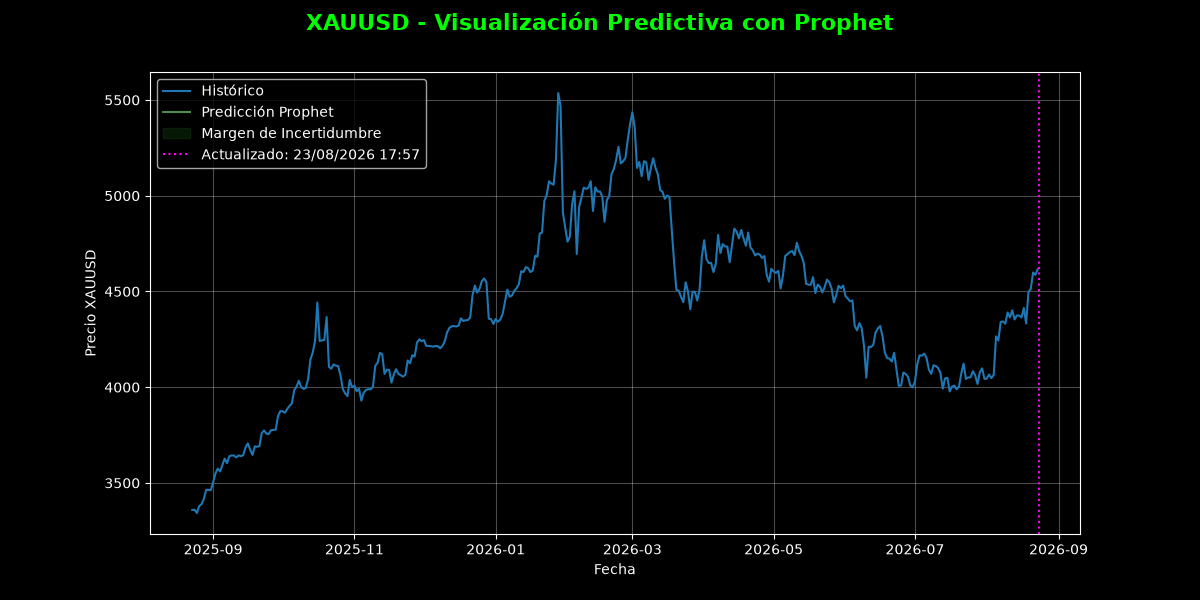

In [71]:
# 📈 Visualización Predictiva Reflectiva con IA (animación fija en GIF)
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime
from prophet import Prophet
from IPython.display import HTML, display, clear_output
import base64

# 1️⃣ Descargar datos históricos
data = yf.download(SYMBOL, period="1y", interval="1d").dropna()

# 2️⃣ Preparar DataFrame limpio para Prophet
df = pd.DataFrame({
    "ds": pd.to_datetime(data.index),
    "y": data["Close"].squeeze().astype(float)
}).dropna()

# 3️⃣ Entrenar modelo Prophet
model = Prophet(
    changepoint_prior_scale=0.8, # Mayor sensibilidad a cambios de tendencia
    daily_seasonality=True, 
    yearly_seasonality=True, 
    interval_width=0.95) # Ajuste de intervalo de confianza al 95%
model.fit(df)

# 4️⃣ Generar predicción a 30 días
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# 5️⃣ Configuración de la figura
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle(f"{SYMBOL_LABEL} - Visualización Predictiva con Prophet",
             fontsize=16, fontweight="bold", color="lime")

# 6️⃣ Fecha y hora de actualización (fijada al momento de generar la animación)
ahora = datetime.now()
etiqueta_actualizacion = f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}"

# 7️⃣ Función de animación con lógica reflectiva
# total_frames debe coincidir con frames= de FuncAnimation más abajo: si no,
# el ciclo revelado→reflejo no completa (o produce índices negativos al
# recortar el forecast, vaciando la línea antes de tiempo).
def update(frame):
    ax.clear()
    total_frames = 40
    alpha = min(frame if frame <= total_frames/2 else total_frames - frame, total_frames/2) / (total_frames/2)
    n_points = int(alpha * len(forecast))

    # Dibujar histórico completo
    ax.plot(df["ds"], df["y"], color="#1f77b4", label="Histórico")
    # Dibujar predicción progresiva
    ax.plot(forecast["ds"][:n_points], forecast["yhat"][:n_points], color="#2ca02c", label="Predicción Prophet")
    ax.fill_between(forecast["ds"][:n_points], forecast["yhat_lower"][:n_points], forecast["yhat_upper"][:n_points],
                    color="#2ca02c", alpha=0.15, label="Margen de Incertidumbre")
    # Marcar fecha y hora de actualización del gráfico
    ax.axvline(ahora, color="magenta", linestyle=":", linewidth=1.5, zorder=5, label=etiqueta_actualizacion)

    ax.legend()
    ax.grid(alpha=0.3) # Mantener fondo oscuro
    ax.set_xlabel("Fecha")
    ax.set_ylabel(f"Precio {SYMBOL_LABEL}")

# 8️⃣ Crear animación reflectiva y guardar como GIF
# Menos fotogramas (40 en vez de 100) para que la generación sea ~2.5x más
# rápida; interval sube a 1000ms para mantener la misma duración total del GIF.
ani = animation.FuncAnimation(fig, update, frames=40, interval=1000, repeat=True)
ani.save(f"{SYMBOL_LABEL}_reflect.gif", writer="pillow") 
plt.close(fig) 

# 9️⃣ Mostrar solo el GIF (sin reproductor ni duplicados)
clear_output()
with open(f"{SYMBOL_LABEL}_reflect.gif", "rb") as f:
    b64 = base64.b64encode(f.read()).decode("utf-8")
display(HTML(f'<img src="data:image/gif;base64,{b64}" style="display:block; margin:auto;" />'))



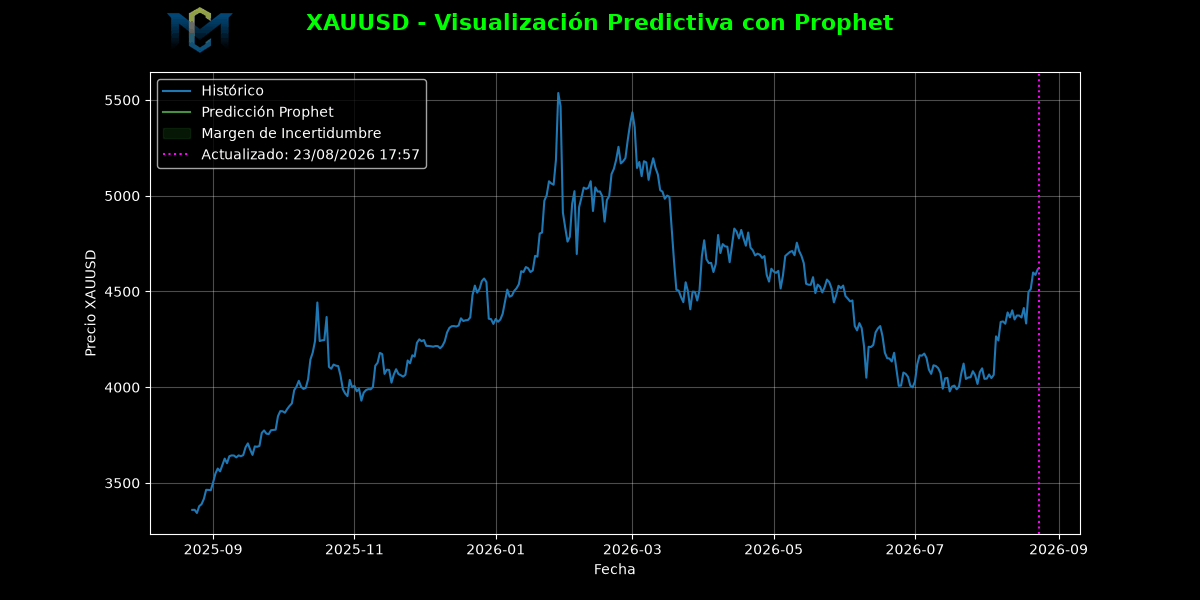

In [72]:
# 📈 Visualización Predictiva Reflectiva con IA + Logo CE (pequeño en esquina superior izquierda)
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime
from prophet import Prophet
from IPython.display import HTML, display, clear_output
import base64
import matplotlib.image as mpimg
from PIL import Image

# 1️⃣ Descargar datos históricos
data = yf.download(SYMBOL, period="1y", interval="1d").dropna()

# 2️⃣ Preparar DataFrame limpio para Prophet
df = pd.DataFrame({
    "ds": pd.to_datetime(data.index),
    "y": data["Close"].squeeze().astype(float)
}).dropna()

# 3️⃣ Entrenar modelo Prophet
model = Prophet(daily_seasonality=True, yearly_seasonality=True, interval_width=0.95)
model.fit(df)

# 4️⃣ Generar predicción a 30 días
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# 5️⃣ Configuración de la figura
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(12, 6))

# Cargar y redimensionar tu logo (asegúrate de tenerlo en la misma carpeta)
logo = Image.open("logoIT2.png")
logo = logo.resize((100, 70))  # tamaño pequeño
logo = np.array(logo)
fig.figimage(logo, xo=150, yo=535, alpha=0.9, zorder=10)  # posición ajustada arriba a la izquierda

fig.suptitle(f"{SYMBOL_LABEL} - Visualización Predictiva con Prophet",
             fontsize=16, fontweight="bold", color="lime")

# 6️⃣ Fecha y hora de actualización (fijada al momento de generar la animación)
ahora = datetime.now()
etiqueta_actualizacion = f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}"

# 7️⃣ Función de animación reflectiva
def update(frame):
    ax.clear()
    total_frames = 40
    alpha = min(frame if frame <= total_frames/2 else total_frames - frame, total_frames/2) / (total_frames/2)
    n_points = int(alpha * len(forecast))

    ax.plot(df["ds"], df["y"], color="#1f77b4", label="Histórico")
    ax.plot(forecast["ds"][:n_points], forecast["yhat"][:n_points], color="#2ca02c", label="Predicción Prophet")
    ax.fill_between(forecast["ds"][:n_points], forecast["yhat_lower"][:n_points], forecast["yhat_upper"][:n_points],
                    color="#2ca02c", alpha=0.15, label="Margen de Incertidumbre")
    # Marcar fecha y hora de actualización del gráfico
    ax.axvline(ahora, color="magenta", linestyle=":", linewidth=1.5, zorder=5, label=etiqueta_actualizacion)
    
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xlabel("Fecha")
    ax.set_ylabel(f"Precio {SYMBOL_LABEL}")

# 8️⃣ Crear animación reflectiva y guardar como GIF
# Menos fotogramas (40 en vez de 100) para que la generación sea ~2.5x más
# rápida; interval sube a 1000ms para mantener la misma duración total del GIF.
ani = animation.FuncAnimation(fig, update, frames=40, interval=1000, repeat=True)
ani.save(f"{SYMBOL_LABEL}_reflect_logo_small.gif", writer="pillow")
plt.close(fig)

# 9️⃣ Mostrar solo el GIF
clear_output()
with open(f"{SYMBOL_LABEL}_reflect_logo_small.gif", "rb") as f:
    b64 = base64.b64encode(f.read()).decode("utf-8")
display(HTML(f'<img src="data:image/gif;base64,{b64}" style="display:block; margin:auto;" />'))


# 📊 Probabilidad de Targets (1D) + Calendario Económico Fundamental

[*********************100%***********************]  1 of 1 completed


📊 Probabilidades históricas (ventanas de 30 días, sobre 731 velas diarias):
- Target 1 alcanzado: 43.37%
- Target 2 alcanzado: 17.69%
- Stoploss tocado: 38.94%

📅 Eventos económicos relevantes para XAUUSD: 17
   Semana: 2026-08-17 → 2026-08-21


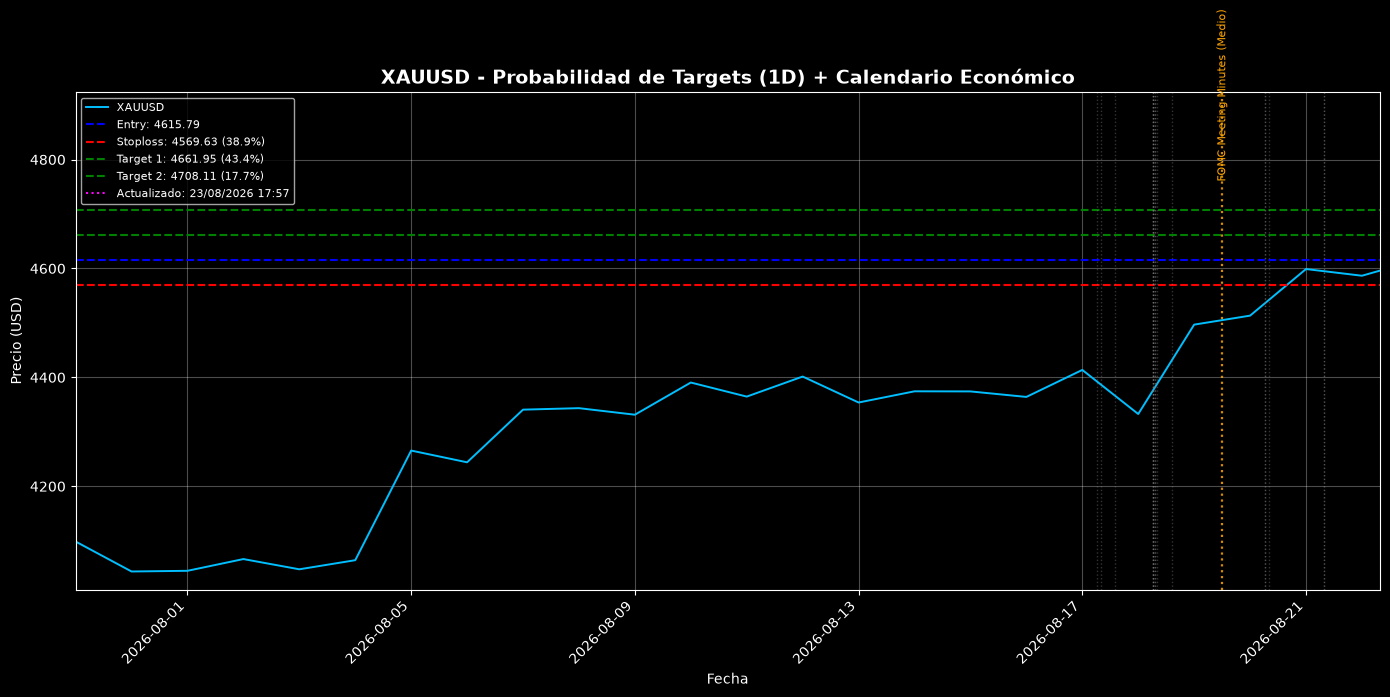

In [73]:
# 📊 Probabilidad de Targets (1D) + Calendario Económico Fundamental
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import find_peaks

# 1️⃣ Descargar datos diarios (histórico amplio para una probabilidad robusta)
data = yf.download(SYMBOL, period="2y", interval="1d").dropna()
close = data["Close"].squeeze().astype(float).values
time = data.index

# 2️⃣ Detectar picos y valles
peaks, _ = find_peaks(close, distance=5)
valleys, _ = find_peaks(-close, distance=5)

# 3️⃣ Definir entrada y objetivos
entry = close[-1]
stoploss = entry * 0.99
target1 = entry * 1.01
target2 = entry * 1.02

# 4️⃣ Calcular probabilidad de alcanzar targets
# Ventanas históricas de 30 velas diarias (~1 mes hacia adelante)
window = 30
results = {"Target1": 0, "Target2": 0, "Stoploss": 0, "Total": 0}

for i in range(len(close) - window):
    segment = close[i:i + window]
    start = segment[0]
    sl = start * 0.99
    t1 = start * 1.01
    t2 = start * 1.02

    # Verificar cuál se alcanza primero
    for price in segment[1:]:
        if price <= sl:
            results["Stoploss"] += 1
            break
        elif price >= t2:
            results["Target2"] += 1
            break
        elif price >= t1:
            results["Target1"] += 1
            break
    results["Total"] += 1

# 5️⃣ Calcular probabilidades
p_stop = results["Stoploss"] / results["Total"] * 100
p_t1 = results["Target1"] / results["Total"] * 100
p_t2 = results["Target2"] / results["Total"] * 100

print(f"📊 Probabilidades históricas (ventanas de {window} días, sobre {len(close)} velas diarias):")
print(f"- Target 1 alcanzado: {p_t1:.2f}%")
print(f"- Target 2 alcanzado: {p_t2:.2f}%")
print(f"- Stoploss tocado: {p_stop:.2f}%")

# 6️⃣ Calendario económico: eventos relevantes para el activo (USD/XAU mueven
# directamente su precio, cotizado en USD; se excluyen otras divisas)
RUTA_CALENDARIO = "calendario_economico_ftmo/economic_calendar.xlsx"
calendario = pd.read_excel(RUTA_CALENDARIO)
calendario["Fechas"] = pd.to_datetime(calendario["Fechas"]).dt.tz_localize(None)
es_relevante = calendario["Instrumento"].str.contains("USD|XAU", case=False, na=False)
calendario_activo = calendario.loc[es_relevante].sort_values("Fechas").reset_index(drop=True)

IMPACTO_LABEL = {0: "Bajo", 1: "Medio", 2: "Alto"}
IMPACTO_COLOR = {0: "gray", 1: "orange", 2: "red"}
calendario_activo["Impacto"] = calendario_activo["Restricciones"].map(IMPACTO_LABEL)

print(f"\n📅 Eventos económicos relevantes para {SYMBOL_LABEL}: {len(calendario_activo)}")
print(f"   Semana: {calendario_activo['Fechas'].min().date()} → {calendario_activo['Fechas'].max().date()}")

# 7️⃣ Visualización: últimas ~4 semanas de velas + semana de eventos económicos por
# delante. Ventana corta (no 90d) para que la semana de eventos no quede
# comprimida en una franja ilegible del lado derecho.
data_reciente = data.tail(25)
close_reciente = data_reciente["Close"].squeeze().astype(float).values
time_reciente = data_reciente.index

plt.figure(figsize=(14, 7))
plt.plot(time_reciente, close_reciente, color="#00bfff", linewidth=1.4, label=SYMBOL_LABEL)
plt.axhline(entry, color="blue", linestyle="--", label=f"Entry: {entry:.2f}")
plt.axhline(stoploss, color="red", linestyle="--", label=f"Stoploss: {stoploss:.2f} ({p_stop:.1f}%)")
plt.axhline(target1, color="green", linestyle="--", label=f"Target 1: {target1:.2f} ({p_t1:.1f}%)")
plt.axhline(target2, color="green", linestyle="--", label=f"Target 2: {target2:.2f} ({p_t2:.1f}%)")

# 8️⃣ Marcar fecha y hora de actualización del gráfico
ahora = datetime.now()
plt.axvline(ahora, color="magenta", linestyle=":", linewidth=1.5, zorder=5,
            label=f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}")

# 9️⃣ Velas fundamentales: eventos económicos de la semana por delante,
# coloreados por nivel de impacto/restricción de FTMO (0=bajo, 1=medio, 2=alto).
# Solo se etiquetan los de impacto medio/alto: con 17 eventos en la semana,
# etiquetarlos todos amontona el texto en los días con varios eventos de bajo
# impacto (p. ej. 8 el mismo día) y lo vuelve ilegible. Los de bajo impacto
# quedan como líneas finas sin texto, para ver la densidad sin ruido visual.
ejes = plt.gca()
y_bajo, y_alto = ejes.get_ylim()
margen = (y_alto - y_bajo) * 0.25
ejes.set_ylim(y_bajo, y_alto + margen)
y_texto = y_alto + margen * 0.1

for _, ev in calendario_activo.iterrows():
    color = IMPACTO_COLOR[ev["Restricciones"]]
    plt.axvline(ev["Fechas"], color=color, linestyle=":",
                linewidth=1.6 if ev["Restricciones"] else 1,
                alpha=0.85 if ev["Restricciones"] else 0.4)
    if ev["Restricciones"] >= 1:
        plt.annotate(f"{ev['Descripción']} ({ev['Impacto']})", xy=(ev["Fechas"], y_texto),
                     rotation=90, fontsize=8, color=color, ha="center", va="bottom", clip_on=False)

plt.xlim(time_reciente.min(), calendario_activo["Fechas"].max() + pd.Timedelta(days=1))
plt.title(f"{SYMBOL_LABEL} - Probabilidad de Targets (1D) + Calendario Económico", fontsize=14, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Precio (USD)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 🎯 Plan de Trading — Sesión de Nueva York (dejar corriendo, sin revisar hasta el cierre)

[*********************100%***********************]  1 of 1 completed


📊 Estadística por killzone de Nueva York (08:00-12:00 America/New_York, 128 sesiones analizadas):
- Target 1 (+1%) tocado antes del cierre: 10.9%
- Target 2 (+2%) tocado antes del cierre: 0.0%
- Stoploss (-1%) tocado antes del cierre: 10.2%
- Ninguno tocado (sigue abierta al cierre): 78.9%

  PLAN DE TRADING — XAUUSD — Killzone de Nueva York
Sesión: Monday 24/08/2026 08:00 → 12:00 (America/New_York)
Estado: ⏳ próxima sesión (aún no abre)
Entrada de referencia: 4615.79  (dato de 23/08 19:00, hace 1.0h)
Stop Loss:  4569.63  (-1.0%)
Target 1:   4661.95  (+1.0%)  — histórico de tocarlo en sesión: 10.9%
Target 2:   4708.11  (+2.0%)  — histórico de tocarlo en sesión: 0.0%
------------------------------------------------------------------------
⚠️  Faltan 12.0h para que abra la killzone. Esta Entrada/SL/TP
    son solo de referencia — antes de colocar la orden, vuelve a ejecutar esta
    celda cerca de las 08:00 (America/New_York) del día de trading para recalcularlos
    con el precio real d

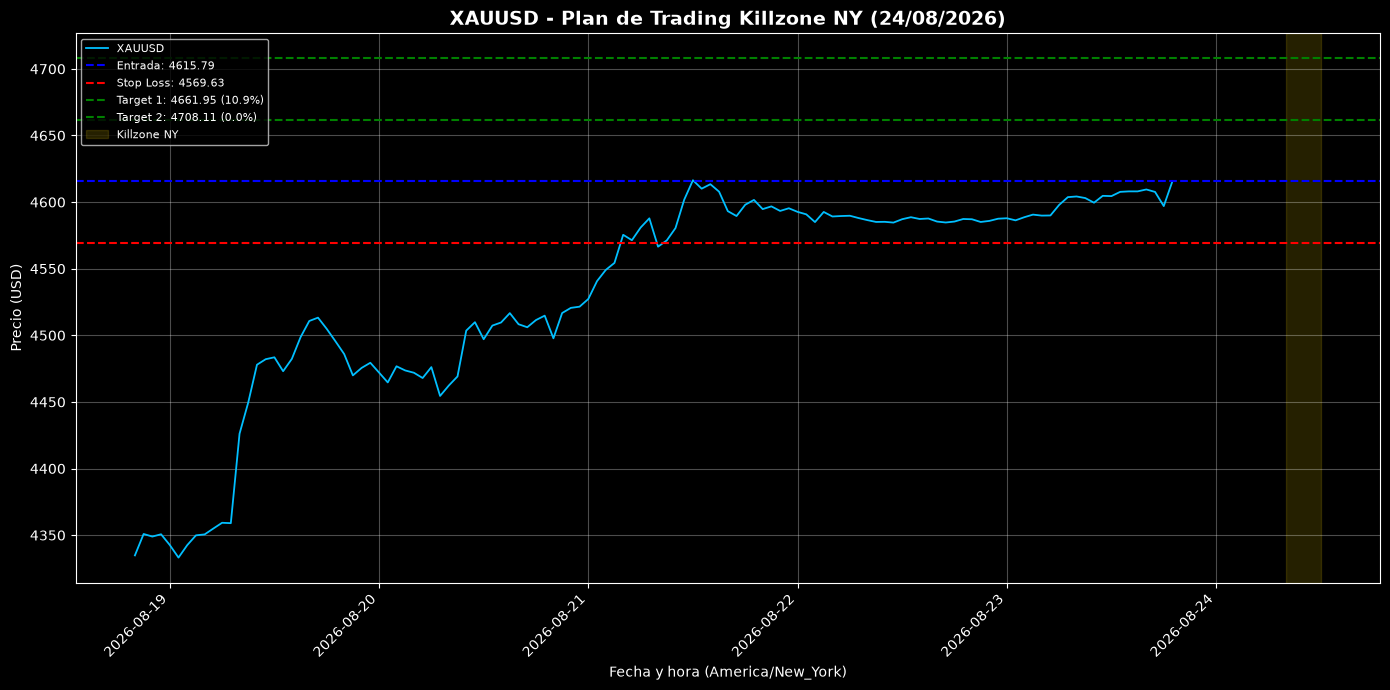

In [74]:
# 🎯 Plan de Trading — Sesión de Nueva York (dejar corriendo, sin revisar hasta el cierre)
#
# Idea: en vez de la probabilidad "a 30 días" de la celda anterior, aquí se mide
# específicamente qué pasa DENTRO de la killzone de Nueva York (08:00-12:00,
# hora America/New_York — misma convención ICT que zonas_alta_probabilidad_smc_eth.ipynb:
# apertura NY + solape con Londres, la ventana de mayor liquidez/movimiento
# direccional del día; la tarde 12:00-17:00 suele ser más lateral y solo añade
# tiempo de exposición al stoploss sin sumar mucha probabilidad real de target).
# Con eso se arma un ticket de trade con Entrada/SL/TP fijos que puedes colocar
# y dejar corriendo sin volver a mirar el gráfico hasta el cierre de la killzone.
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

SESION_INICIO, SESION_FIN = "08:00", "12:00"
ZONA_NY = "America/New_York"

# 1️⃣ Descargar velas 1h (suficiente historial para estadística por sesión)
data_1h = yf.download(SYMBOL, period="180d", interval="1h").dropna()
if isinstance(data_1h.columns, pd.MultiIndex):
    data_1h.columns = data_1h.columns.get_level_values(0)
data_1h.index = data_1h.index.tz_convert(ZONA_NY) if data_1h.index.tz is not None else data_1h.index.tz_localize("UTC").tz_convert(ZONA_NY)

# 2️⃣ Para cada killzone de NY (solo días hábiles), ver qué se toca primero desde
# el precio de apertura: Target1 (+1%), Target2 (+2%) o Stoploss (-1%)
resultados_sesion = {"Target1": 0, "Target2": 0, "Stoploss": 0, "Total": 0}

for dia, grupo in data_1h.groupby(data_1h.index.date):
    if pd.Timestamp(dia).dayofweek >= 5:  # fin de semana: no es sesión de NY
        continue
    sesion = grupo.between_time(SESION_INICIO, SESION_FIN)
    if len(sesion) < 2:
        continue
    apertura = float(sesion["Close"].iloc[0])
    sl = apertura * 0.99
    t1 = apertura * 1.01
    t2 = apertura * 1.02
    resultado = None
    for precio in sesion["Close"].iloc[1:]:
        if precio <= sl:
            resultado = "Stoploss"; break
        elif precio >= t2:
            resultado = "Target2"; break
        elif precio >= t1:
            resultado = "Target1"; break
    if resultado:
        resultados_sesion[resultado] += 1
    resultados_sesion["Total"] += 1

p_stop_s = resultados_sesion["Stoploss"] / resultados_sesion["Total"] * 100
p_t1_s = resultados_sesion["Target1"] / resultados_sesion["Total"] * 100
p_t2_s = resultados_sesion["Target2"] / resultados_sesion["Total"] * 100
p_sin_tocar = 100 - p_stop_s - p_t1_s - p_t2_s

print(f"📊 Estadística por killzone de Nueva York ({SESION_INICIO}-{SESION_FIN} {ZONA_NY}, "
      f"{resultados_sesion['Total']} sesiones analizadas):")
print(f"- Target 1 (+1%) tocado antes del cierre: {p_t1_s:.1f}%")
print(f"- Target 2 (+2%) tocado antes del cierre: {p_t2_s:.1f}%")
print(f"- Stoploss (-1%) tocado antes del cierre: {p_stop_s:.1f}%")
print(f"- Ninguno tocado (sigue abierta al cierre): {p_sin_tocar:.1f}%")

# 3️⃣ Ubicar la killzone de NY vigente (si "ahora" cae dentro) o la próxima hábil
def sesion_ny_vigente_o_proxima(ahora_ny):
    dia = ahora_ny.normalize()
    while True:
        apertura = dia + pd.Timedelta(hours=8)
        cierre = dia + pd.Timedelta(hours=12)
        if dia.dayofweek < 5 and ahora_ny <= cierre:
            return apertura, cierre
        dia += pd.Timedelta(days=1)

ahora_ny = pd.Timestamp.now(tz=ZONA_NY)
apertura_sesion, cierre_sesion = sesion_ny_vigente_o_proxima(ahora_ny)
sesion_en_curso = apertura_sesion <= ahora_ny <= cierre_sesion

# 4️⃣ Definir niveles: entrada = último precio disponible. OJO: esto es una FOTO
# del momento en que corres la celda, no del momento en que abre la killzone.
# Si los ejecutas con horas/días de anticipación, el precio real de apertura de
# sesión puede haberse movido (más aún con PAXG-USD, que cotiza 24/7 mientras el
# oro real no opera en fin de semana) — hay que refrescar esta celda cerca de la
# apertura para que Entrada/SL/TP reflejen el precio real al que vas a entrar.
entrada = float(data_1h["Close"].iloc[-1])
entrada_timestamp = data_1h.index[-1]
horas_desde_dato = (ahora_ny - entrada_timestamp).total_seconds() / 3600
horas_hasta_apertura = (apertura_sesion - ahora_ny).total_seconds() / 3600
stoploss_s = entrada * 0.99
target1_s = entrada * 1.01
target2_s = entrada * 1.02

print()
print("=" * 72)
print(f"  PLAN DE TRADING — {SYMBOL_LABEL} — Killzone de Nueva York")
print("=" * 72)
print(f"Sesión: {apertura_sesion.strftime('%A %d/%m/%Y %H:%M')} → {cierre_sesion.strftime('%H:%M')} ({ZONA_NY})")
print(f"Estado: {'🟢 en curso ahora mismo' if sesion_en_curso else '⏳ próxima sesión (aún no abre)'}")
print(f"Entrada {'de referencia' if not sesion_en_curso else 'actual'}: {entrada:.2f}  "
      f"(dato de {entrada_timestamp.strftime('%d/%m %H:%M')}, hace {horas_desde_dato:.1f}h)")
print(f"Stop Loss:  {stoploss_s:.2f}  (-1.0%)")
print(f"Target 1:   {target1_s:.2f}  (+1.0%)  — histórico de tocarlo en sesión: {p_t1_s:.1f}%")
print(f"Target 2:   {target2_s:.2f}  (+2.0%)  — histórico de tocarlo en sesión: {p_t2_s:.1f}%")
if not sesion_en_curso and horas_hasta_apertura > 1:
    print("-" * 72)
    print(f"⚠️  Faltan {horas_hasta_apertura:.1f}h para que abra la killzone. Esta Entrada/SL/TP")
    print("    son solo de referencia — antes de colocar la orden, vuelve a ejecutar esta")
    print(f"    celda cerca de las {SESION_INICIO} ({ZONA_NY}) del día de trading para recalcularlos")
    print("    con el precio real de apertura (puede haberse movido, sobre todo si hay fin")
    print("    de semana de por medio: PAXG-USD cotiza 24/7 pero el oro real no).")
print("-" * 72)
print("Para dejarla corriendo sin volver a revisar el gráfico:")
print("  1. Coloca la orden con Entrada/SL/TP1/TP2 de arriba antes de que abra la killzone.")
print("  2. Si tu bróker permite cierre parcial, usa TP1 para asegurar la mitad")
print("     y deja el resto corriendo hasta TP2 o el cierre de la killzone.")
print(f"  3. Regla de tiempo: si a las {cierre_sesion.strftime('%H:%M')} ({ZONA_NY}) ninguno se")
print("     tocó, cierra la posición manualmente a mercado — no la dejes abierta")
print("     para la tarde de NY ni la sesión siguiente (fuera de este análisis).")
print("=" * 72)

# 5️⃣ Calendario económico del día de la sesión (riesgo fundamental específico
# de HOY, no de toda la semana)
RUTA_CALENDARIO = "calendario_economico_ftmo/economic_calendar.xlsx"
IMPACTO_LABEL = {0: "Bajo", 1: "Medio", 2: "Alto"}
IMPACTO_COLOR = {0: "gray", 1: "orange", 2: "red"}

calendario_ny = pd.read_excel(RUTA_CALENDARIO)
calendario_ny["Fechas"] = pd.to_datetime(calendario_ny["Fechas"]).dt.tz_convert(ZONA_NY)
calendario_ny = calendario_ny.loc[calendario_ny["Instrumento"].str.contains("USD|XAU", case=False, na=False)]
calendario_ny["Impacto"] = calendario_ny["Restricciones"].map(IMPACTO_LABEL)
eventos_dia = calendario_ny[calendario_ny["Fechas"].dt.date == apertura_sesion.date()].sort_values("Fechas")

if len(eventos_dia):
    print(f"\n📅 Eventos económicos relevantes ese día ({apertura_sesion.date()}): {len(eventos_dia)}")
    for _, ev in eventos_dia.iterrows():
        print(f"   {ev['Fechas'].strftime('%H:%M')} — {ev['Descripción']} ({ev['Impacto']})")
else:
    print(f"\n📅 Sin eventos económicos relevantes para {SYMBOL_LABEL} ese día.")

# 6️⃣ Visualización: velas 1h recientes + niveles + ventana de la killzone NY
data_reciente = data_1h.tail(5 * 24)
close_reciente = data_reciente["Close"].squeeze().astype(float).values
time_reciente = data_reciente.index

plt.figure(figsize=(14, 7))
plt.plot(time_reciente, close_reciente, color="#00bfff", linewidth=1.3, label=SYMBOL_LABEL)
plt.axhline(entrada, color="blue", linestyle="--", label=f"Entrada: {entrada:.2f}")
plt.axhline(stoploss_s, color="red", linestyle="--", label=f"Stop Loss: {stoploss_s:.2f}")
plt.axhline(target1_s, color="green", linestyle="--", label=f"Target 1: {target1_s:.2f} ({p_t1_s:.1f}%)")
plt.axhline(target2_s, color="green", linestyle="--", label=f"Target 2: {target2_s:.2f} ({p_t2_s:.1f}%)")

# Sombrear la ventana de la killzone de NY vigente/próxima
plt.axvspan(apertura_sesion, cierre_sesion, color="gold", alpha=0.15, label="Killzone NY")

# Eventos económicos de ese día específico
y_alto = max(close_reciente.max(), target2_s)
for _, ev in eventos_dia.iterrows():
    color = IMPACTO_COLOR[ev["Restricciones"]]
    plt.axvline(ev["Fechas"], color=color, linestyle=":", linewidth=1.6, alpha=0.85)
    plt.annotate(ev["Descripción"], xy=(ev["Fechas"], y_alto), rotation=90,
                 fontsize=7, color=color, ha="center", va="bottom")

plt.title(f"{SYMBOL_LABEL} - Plan de Trading Killzone NY ({apertura_sesion.strftime('%d/%m/%Y')})",
          fontsize=14, fontweight="bold")
plt.xlabel(f"Fecha y hora ({ZONA_NY})")
plt.ylabel("Precio (USD)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

[*********************100%***********************]  1 of 1 completed


📊 Probabilidades condicionales por tipo de patrón:
    Patrón  Target1 (%)  Target2 (%)  Stoploss (%)
0  Alcista    23.537415          0.0      0.272109
1  Bajista     0.490196          0.0      7.156863
2  Lateral     0.277778          0.0      0.000000


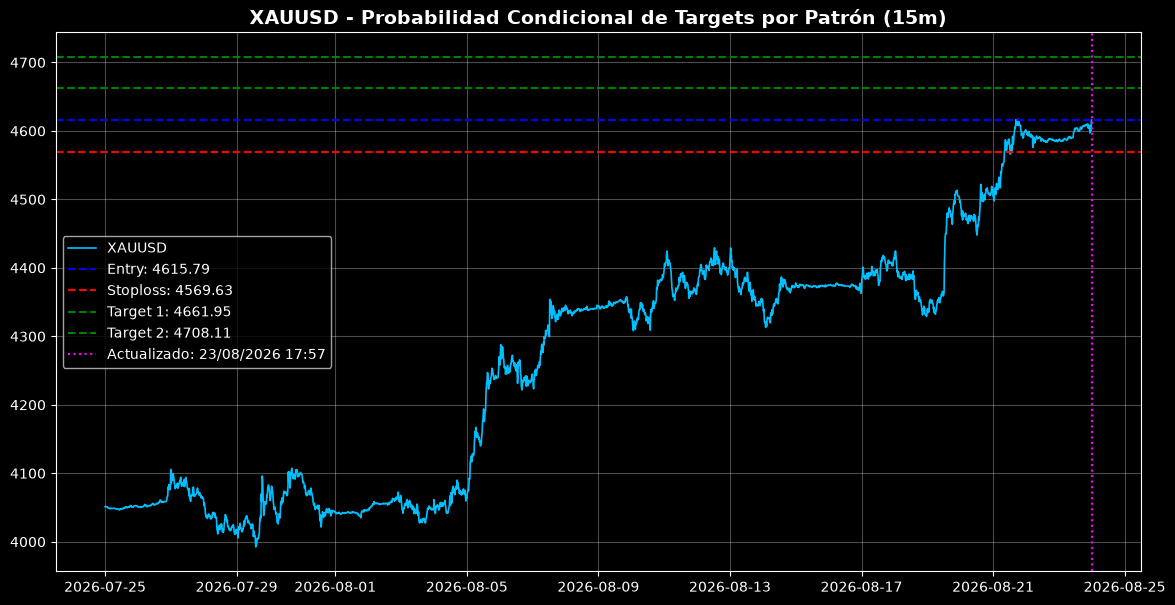

In [75]:
# 📊 Probabilidad condicional por tipo de patrón (ETH/USD)
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import find_peaks

# 1️⃣ Descargar datos en intervalos de 15 minutos
data = yf.download(SYMBOL, period="30d", interval="15m").dropna()
close = data["Close"].squeeze().astype(float).values
time = data.index

# 2️⃣ Detectar picos y valles
peaks, _ = find_peaks(close, distance=10)
valleys, _ = find_peaks(-close, distance=10)

# 3️⃣ Definir entrada y objetivos
entry = close[-1]
stoploss = entry * 0.99
target1 = entry * 1.01
target2 = entry * 1.02

# 4️⃣ Calcular probabilidad condicional por tipo de patrón
window = 30
results = {
    "Alcista": {"Target1":0, "Target2":0, "Stoploss":0, "Total":0},
    "Bajista": {"Target1":0, "Target2":0, "Stoploss":0, "Total":0},
    "Lateral": {"Target1":0, "Target2":0, "Stoploss":0, "Total":0}
}

for i in range(len(close)-window):
    segment = close[i:i+window]
    start = segment[0]
    sl = start * 0.99
    t1 = start * 1.01
    t2 = start * 1.02

    # Clasificar tipo de patrón según pendiente
    slope = np.polyfit(range(window), segment, 1)[0]
    if slope > 0.05:
        pattern = "Alcista"
    elif slope < -0.05:
        pattern = "Bajista"
    else:
        pattern = "Lateral"

    # Verificar cuál se alcanza primero
    for price in segment[1:]:
        if price <= sl:
            results[pattern]["Stoploss"] += 1
            break
        elif price >= t2:
            results[pattern]["Target2"] += 1
            break
        elif price >= t1:
            results[pattern]["Target1"] += 1
            break
    results[pattern]["Total"] += 1

# 5️⃣ Calcular probabilidades condicionales
def prob(r, key):
    return r[key]/r["Total"]*100 if r["Total"] > 0 else 0

summary = pd.DataFrame({
    "Patrón": ["Alcista", "Bajista", "Lateral"],
    "Target1 (%)": [prob(results[p],"Target1") for p in results],
    "Target2 (%)": [prob(results[p],"Target2") for p in results],
    "Stoploss (%)": [prob(results[p],"Stoploss") for p in results]
})

print("📊 Probabilidades condicionales por tipo de patrón:")
print(summary)

# 6️⃣ Visualización
plt.figure(figsize=(14,7))
plt.plot(time, close, color="#00bfff", linewidth=1.2, label=SYMBOL_LABEL)
plt.axhline(entry, color="blue", linestyle="--", label=f"Entry: {entry:.2f}")
plt.axhline(stoploss, color="red", linestyle="--", label=f"Stoploss: {stoploss:.2f}")
plt.axhline(target1, color="green", linestyle="--", label=f"Target 1: {target1:.2f}")
plt.axhline(target2, color="green", linestyle="--", label=f"Target 2: {target2:.2f}")

# 7️⃣ Marcar fecha y hora de actualización del gráfico
ahora = datetime.now()
ahora_plot = ahora.astimezone(time.tz) if time.tz is not None else ahora
plt.axvline(ahora_plot, color="magenta", linestyle=":", linewidth=1.5, zorder=5,
            label=f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}")

plt.title(f"{SYMBOL_LABEL} - Probabilidad Condicional de Targets por Patrón (15m)", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 📉 Probabilidad condicional por tipo de patrón — VENTA (15m)

[*********************100%***********************]  1 of 1 completed


📉 Probabilidades condicionales por tipo de patrón — VENTA:
    Patrón  Target1 (%)  Target2 (%)  Stoploss (%)
0  Alcista     0.272109          0.0     23.537415
1  Bajista     7.156863          0.0      0.490196
2  Lateral     0.000000          0.0      0.277778


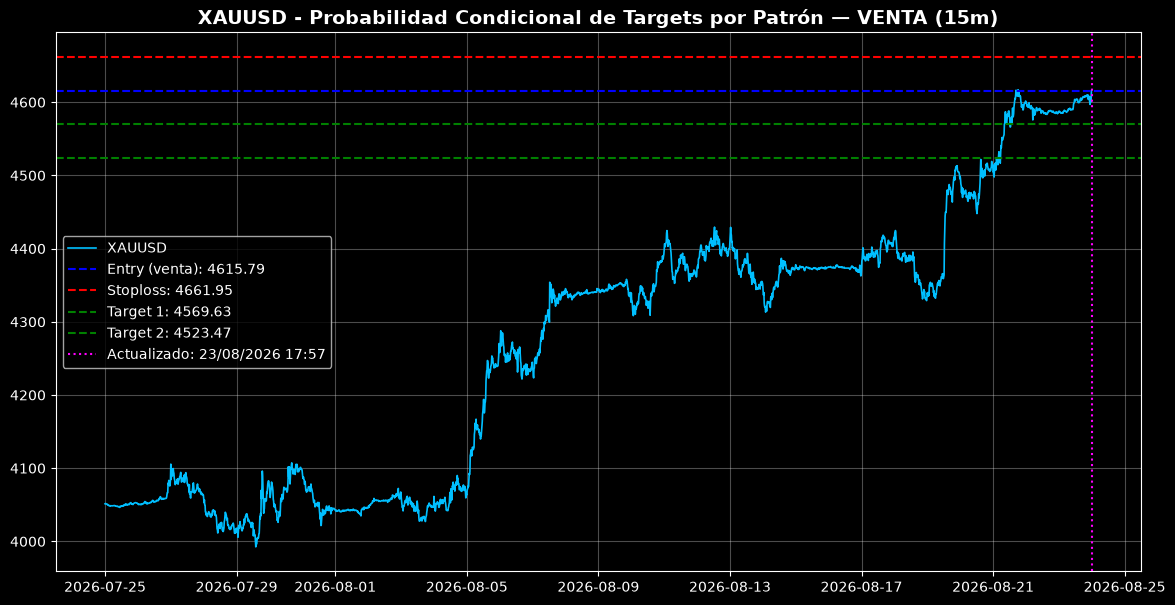

In [76]:
# 📉 Probabilidad condicional por tipo de patrón — VENTA (15m)
#
# Espejo exacto de la celda "Probabilidad condicional por tipo de patrón"
# (compra), pero para posiciones de VENTA: Stop Loss por ENCIMA de la entrada,
# Target1/Target2 por DEBAJO. Se deja en una celda separada a propósito, para
# no mezclar ambas lógicas y poder comparar compra vs. venta con criterio.
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from scipy.signal import find_peaks

# 1️⃣ Descargar datos en intervalos de 15 minutos
data = yf.download(SYMBOL, period="30d", interval="15m").dropna()
close = data["Close"].squeeze().astype(float).values
time = data.index

# 2️⃣ Detectar picos y valles
peaks, _ = find_peaks(close, distance=10)
valleys, _ = find_peaks(-close, distance=10)

# 3️⃣ Definir entrada y objetivos de VENTA (invertido respecto a compra)
entry = close[-1]
stoploss = entry * 1.01   # +1%, por ENCIMA de la entrada
target1 = entry * 0.99    # -1%, por DEBAJO de la entrada
target2 = entry * 0.98    # -2%, por DEBAJO de la entrada

# 4️⃣ Calcular probabilidad condicional por tipo de patrón (misma clasificación
# Alcista/Bajista/Lateral que la celda de compra, pero midiendo el resultado
# de una VENTA abierta al inicio de cada ventana)
window = 30
results = {
    "Alcista": {"Target1":0, "Target2":0, "Stoploss":0, "Total":0},
    "Bajista": {"Target1":0, "Target2":0, "Stoploss":0, "Total":0},
    "Lateral": {"Target1":0, "Target2":0, "Stoploss":0, "Total":0}
}

for i in range(len(close)-window):
    segment = close[i:i+window]
    start = segment[0]
    sl = start * 1.01
    t1 = start * 0.99
    t2 = start * 0.98

    # Clasificar tipo de patrón según pendiente
    slope = np.polyfit(range(window), segment, 1)[0]
    if slope > 0.05:
        pattern = "Alcista"
    elif slope < -0.05:
        pattern = "Bajista"
    else:
        pattern = "Lateral"

    # Verificar cuál se alcanza primero (invertido: SL arriba, targets abajo)
    for price in segment[1:]:
        if price >= sl:
            results[pattern]["Stoploss"] += 1
            break
        elif price <= t2:
            results[pattern]["Target2"] += 1
            break
        elif price <= t1:
            results[pattern]["Target1"] += 1
            break
    results[pattern]["Total"] += 1

# 5️⃣ Calcular probabilidades condicionales
def prob(r, key):
    return r[key]/r["Total"]*100 if r["Total"] > 0 else 0

summary = pd.DataFrame({
    "Patrón": ["Alcista", "Bajista", "Lateral"],
    "Target1 (%)": [prob(results[p],"Target1") for p in results],
    "Target2 (%)": [prob(results[p],"Target2") for p in results],
    "Stoploss (%)": [prob(results[p],"Stoploss") for p in results]
})

print("📉 Probabilidades condicionales por tipo de patrón — VENTA:")
print(summary)

# 6️⃣ Visualización
plt.figure(figsize=(14,7))
plt.plot(time, close, color="#00bfff", linewidth=1.2, label=SYMBOL_LABEL)
plt.axhline(entry, color="blue", linestyle="--", label=f"Entry (venta): {entry:.2f}")
plt.axhline(stoploss, color="red", linestyle="--", label=f"Stoploss: {stoploss:.2f}")
plt.axhline(target1, color="green", linestyle="--", label=f"Target 1: {target1:.2f}")
plt.axhline(target2, color="green", linestyle="--", label=f"Target 2: {target2:.2f}")

# 7️⃣ Marcar fecha y hora de actualización del gráfico
ahora = datetime.now()
ahora_plot = ahora.astimezone(time.tz) if time.tz is not None else ahora
plt.axvline(ahora_plot, color="magenta", linestyle=":", linewidth=1.5, zorder=5,
            label=f"Actualizado: {ahora.strftime('%d/%m/%Y %H:%M')}")

plt.title(f"{SYMBOL_LABEL} - Probabilidad Condicional de Targets por Patrón — VENTA (15m)",
          fontsize=14, fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# 🧠 Estrategia Institucional SMC — Sesgo Diario + Order Blocks + Barridas de Liquidez

Reemplaza la version anterior de esta celda (que confirmaba "tendencia" con el primer cierre mas alla de un swing en 5m/15m/1h, sin exigir retest ni distinguir una barrida de liquidez de una continuacion real). Esa logica dio una señal alcista falsa justo antes de que el precio barriera el maximo de ~4630 y revirtiera de inmediato — la operacion que se ejecuto siguiendola perdio.

Esta version importa el motor SMC/ICT ya maduro y en produccion en `oro_dashboard/core/smc_zones.py` (el mismo que usa `eth_dashboard` para ETH) en vez de reescribir la logica aqui — una sola fuente de verdad; este notebook queda como consumidor liviano para exploracion manual. **Requiere que el kernel de este notebook tenga instalado `streamlit`** (ya esta en `oro_dashboard/.venv`; en otro entorno, `pip install streamlit`).

Reglas de oro que aplica:
- Sesgo macro en **1D** (Daily) — filtra señales que no calzan con la tendencia de fondo (la temporalidad que el usuario pidio sumar).
- Una ruptura de estructura solo cuenta como señal despues de que el precio la **retestea** (no en la barra de la ruptura misma).
- Exige una **barrida de liquidez confirmada** (patron AMD: Acumulacion-Manipulacion-Distribucion) cerca de la ruptura — sin ella, no hay entrada.
- Riesgo/Beneficio minimo 1:2, con Stop Loss basado en ATR (no un % fijo).


In [ ]:
# 🧠 Estrategia Institucional SMC — Sesgo Diario + Order Blocks + Barridas de Liquidez
#
# Importa el motor ya maduro de oro_dashboard/core (una sola fuente de verdad, en vez
# de reescribir aqui la logica de swings/BOS/barridas — ver celda markdown de arriba).
import sys
from pathlib import Path

ORO_DASHBOARD_DIR = Path.cwd() / "oro_dashboard"
if not ORO_DASHBOARD_DIR.exists():
    ORO_DASHBOARD_DIR = Path("oro_dashboard").resolve()
sys.path.insert(0, str(ORO_DASHBOARD_DIR))

import matplotlib.pyplot as plt
from core.data import fetch_interval
from core.smc_zones import multi_timeframe_bias, zone_stats
from core import config as oro_config

# 1️⃣ Descargar Diario (sesgo) / 1h (estructura) / 5m (entrada) reales
df_bias = fetch_interval("1d")
df_structure = fetch_interval("1h")
df_entry = fetch_interval("5m")

# 2️⃣ Motor completo: sesgo macro + order blocks (con retest) + barridas de liquidez +
#    entradas de alta probabilidad (retest + patron AMD + RR >= 1:2)
result = multi_timeframe_bias(df_bias, df_structure, df_entry)
stats = zone_stats(result["structure_zones"])

print("=" * 72)
print(f"  ESTRATEGIA INSTITUCIONAL SMC — {oro_config.SYMBOL_LABEL}")
print("=" * 72)
print(f"Sesgo macro ({oro_config.ICT_BIAS_INTERVAL}): {result['macro_bias'].upper()}")
if result["macro_mss"]:
    mss = result["macro_mss"]
    print(f"  ⚡ Ultimo Market Structure Shift: giro {mss['kind']} en {mss['level']:.2f}")
print(f"Precio actual: {result['current_price']:.2f}")
print(f"Order blocks en {oro_config.ICT_STRUCTURE_INTERVAL}: {stats['total']} "
      f"(continuo {stats['continuo_pct']:.1f}% · fallo {stats['fallo_pct']:.1f}%)")

if result["structure_sweeps"]:
    last_sweep = result["structure_sweeps"][-1]
    t = df_structure.index[last_sweep["idx"]]
    print(f"\n🎣 Ultima barrida de liquidez ({oro_config.ICT_STRUCTURE_INTERVAL}): "
          f"{last_sweep['kind']} en {last_sweep['level']:.2f} ({t}) — "
          "spike que perfora un swing y revierte: tipicamente una trampa de stops, no continuacion.")

print("\n" + "-" * 72)
if result["high_probability_setups"]:
    print(f"🎯 {len(result['high_probability_setups'])} entrada(s) de alta probabilidad "
          f"(retest confirmado + barrida de liquidez AMD + RR >= 1:{oro_config.ICT_MIN_RR:.0f}):")
    for s in result["high_probability_setups"]:
        print(f"  {s['direccion']}: {s['motivo']}")
        print(f"    Zona {s['zona_bottom']:.2f}-{s['zona_top']:.2f} | SL {s['sl']:.2f} | TP {s['tp']:.2f} | RR {s['rr']:.2f}")
else:
    print("Sin entradas que cumplan las reglas de oro ahora mismo (order block retesteado + "
          "barrida de liquidez confirmada + RR >= 1:2, alineado con el sesgo diario).")
    print("No es lo mismo que 'sin oportunidad' — es 'esperar' a que se cumplan las condiciones.")
print("=" * 72)

# 3️⃣ Visualizacion: estructura 1h con order blocks (zonas sombreadas) y barridas de
#    liquidez marcadas (X) — el patron que genero la señal falsa anterior queda visible
#    como una barrida, no como una ruptura limpia.
plt.style.use("dark_background")
fig, ax = plt.subplots(figsize=(14, 7))
ventana = 200
reciente = df_structure.tail(ventana)
ax.plot(reciente.index, reciente["close"], color="#00bfff", linewidth=1.2, label=oro_config.SYMBOL_LABEL)

corte = len(df_structure) - ventana
labeled_zone_kinds = set()
for zone in result["structure_zones"]:
    if zone["end_idx"] < corte:
        continue
    x0 = df_structure.index[max(0, zone["start_idx"])]
    x1 = df_structure.index[min(zone["end_idx"], len(df_structure) - 1)]
    color = "lime" if zone["kind"] == "bullish" else "red"
    alpha = 0.06 if zone["status"] == "fallo" else 0.16
    label = None
    if zone["kind"] not in labeled_zone_kinds:
        label = f"Order Block {'alcista' if zone['kind'] == 'bullish' else 'bajista'}"
        labeled_zone_kinds.add(zone["kind"])
    ax.axvspan(x0, x1, color=color, alpha=alpha, label=label)

labeled_sweep_kinds = set()
for sweep in result["structure_sweeps"]:
    if sweep["idx"] < corte:
        continue
    t = df_structure.index[sweep["idx"]]
    color = "red" if sweep["kind"] == "bearish" else "lime"
    label = None
    if sweep["kind"] not in labeled_sweep_kinds:
        label = f"Barrida {'alcista' if sweep['kind'] == 'bullish' else 'bajista'}"
        labeled_sweep_kinds.add(sweep["kind"])
    ax.scatter([t], [sweep["level"]], color=color, marker="x", s=100, zorder=5, label=label)

ax.set_title(
    f"{oro_config.SYMBOL_LABEL} - Estructura SMC ({oro_config.ICT_STRUCTURE_INTERVAL}) - "
    f"Sesgo diario: {result['macro_bias'].upper()}",
    fontsize=14, fontweight="bold",
)
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
